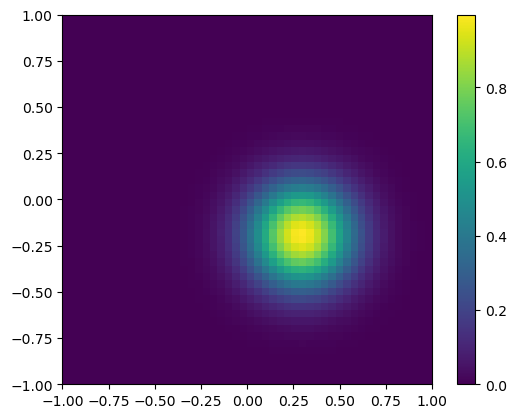

In [18]:
"""
1. place cell 3개를 다른 위치에 두고 한 figure에 3개 firing map 그리기.
2. 랜덤 워크 trajectory(1000 step)에 따라 firing rate 샘플링 → spike 시뮬레이션.
3. grid cell 패턴(6각 격자)을 sinusoid 합으로 근사해 시각화.
"""

import numpy as np
import matplotlib.pyplot as plt

grid = np.linspace(-1, 1, 50)
X, Y = np.meshgrid(grid, grid)

# TODO: 중심 (cx, cy), 폭 sigma 가우시안 place field
cx, cy, sigma = 0.3, -0.2, 0.2
fire_func = lambda X,Y,cx,cy,sig: np.exp(-((X-cx)**2 + (Y-cy)**2) / (2*sig**2))
firing_rate = fire_func(X,Y,cx,cy,sigma)

plt.imshow(firing_rate, extent=[-1,1,-1,1], origin='lower')
plt.colorbar()
plt.show()

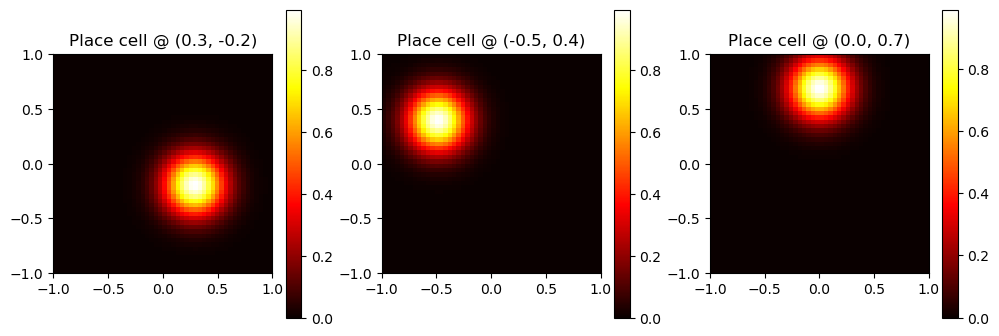

In [19]:
# 1. place cell 3개를 다른 위치에 두고 한 figure에 3개 firing map 그리기.

fig, axes = plt.subplots(1,3, figsize=(12,4))
centers = [(0.3,-0.2), (-0.5,0.4), (0.0,0.7)]

for ax, (cx, cy) in zip(axes, centers):
    firing_rate = fire_func(X,Y,cx,cy,sigma)

    im = ax.imshow(firing_rate, extent=[-1,1,-1,1], origin='lower', cmap='hot')
    ax.set_title(f'Place cell @ ({cx}, {cy})')
    fig.colorbar(im, ax=ax)

plt.show()

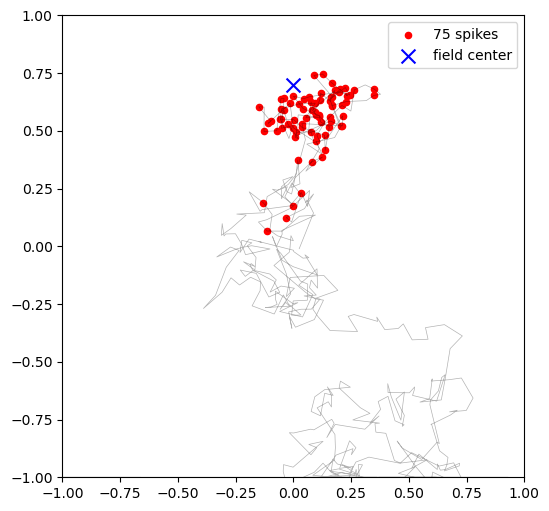

In [32]:
# 2. 랜덤 워크 trajectory(1000 step)에 따라 firing rate 샘플링 → spike 시뮬레이션.

steps = np.random.randn(1000, 2) * 0.05
traj = np.cumsum(steps, axis=0)
traj = np.clip(traj, -1, 1)

rate = fire_func(traj[:,0],traj[:,1],cx,cy,sigma)

spikes = np.random.poisson(rate * 20 * 0.1)

plt.figure(figsize=(6, 6))
plt.plot(traj[:, 0], traj[:, 1], 'k-', alpha=0.3, linewidth=0.5)   # 궤적
plt.scatter(traj[spikes > 0, 0], traj[spikes > 0, 1],
            c='red', s=20, label=f'{(spikes>0).sum()} spikes')
plt.scatter([cx], [cy], c='blue', marker='x', s=100, label='field center')
plt.xlim(-1, 1); plt.ylim(-1, 1)
plt.legend(); plt.gca().set_aspect('equal')
plt.show()

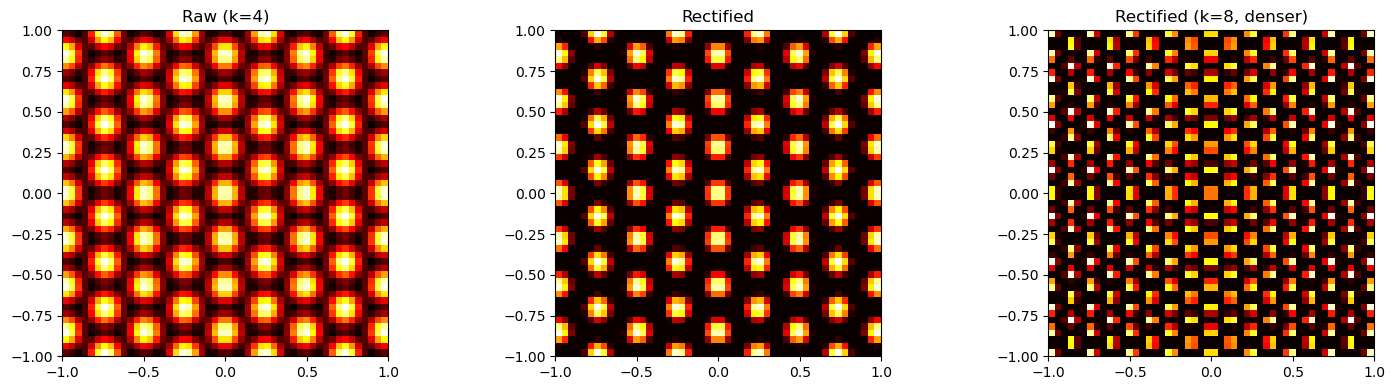

In [36]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 원본
G1 = sum(np.cos(2*np.pi*4 * (np.cos(t)*X + np.sin(t)*Y)) for t in thetas)
axes[0].imshow(G1, extent=[-1,1,-1,1], origin='lower', cmap='hot')
axes[0].set_title('Raw (k=4)')

# Rectified
axes[1].imshow(np.maximum(G1, 0), extent=[-1,1,-1,1], origin='lower', cmap='hot')
axes[1].set_title('Rectified')

# 촘촘한 격자
G2 = sum(np.cos(2*np.pi*8 * (np.cos(t)*X + np.sin(t)*Y)) for t in thetas)
axes[2].imshow(np.maximum(G2, 0), extent=[-1,1,-1,1], origin='lower', cmap='hot')
axes[2].set_title('Rectified (k=8, denser)')

plt.tight_layout()
plt.show()